## 퍼셉트론 & 딥러닝 기초_사전과제_안가은

### 1. 퍼셉트론 : 초기 형태의 인공신경망
#### 1-1) 퍼셉트론의 출력값 구하는 절차

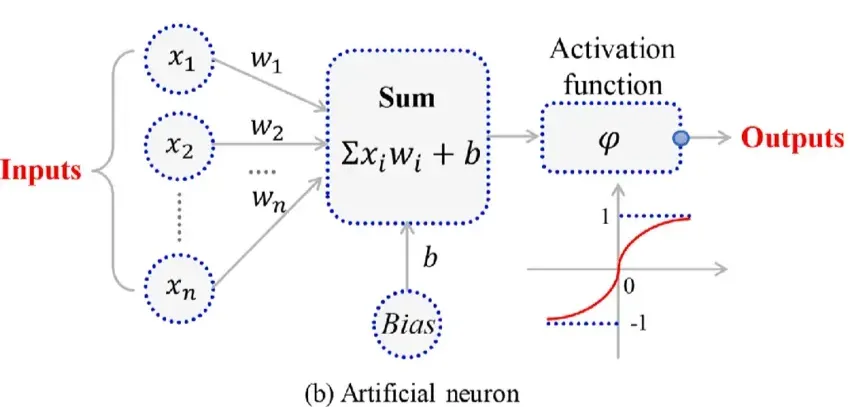

> 인공신경망 구조.

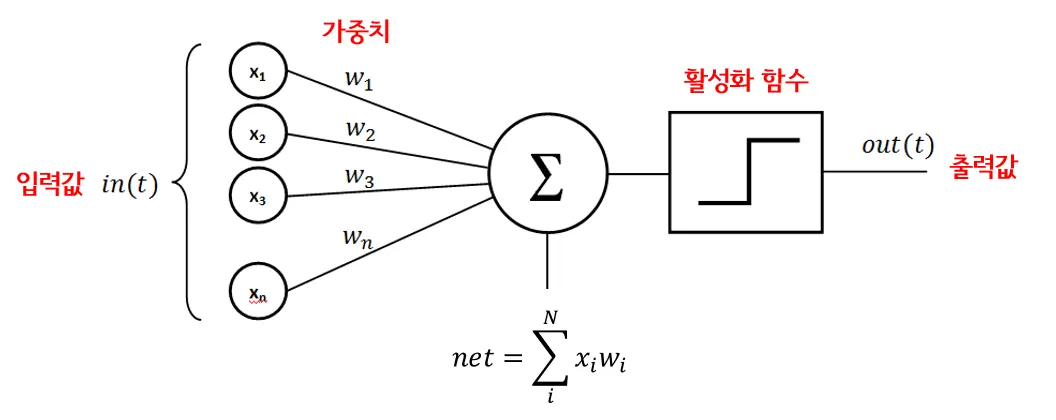

> 퍼셉트론 구조

1. 입력값과 가중치를 곱한다 (x1*w1)
2. 곱한값들의 총합을 구한다 (x1*w1 + x2*w2 + ... + x_n*w_n)
3. 총합이 임계값($\theta$)을 넘으면 1, 넘지 않으면 0을 출력한다 (=step 활성화 함수)
* training(학습): 원하는 출력값을 내보내도록 가중치를 조정해나가는 작업.

* 임계값과 편향
  1. 임계값($\theta$): step function에 사용된 임계치. 가중합이 임계값을 넘으면 1, 넘지 못하면 0을 출력함.            
   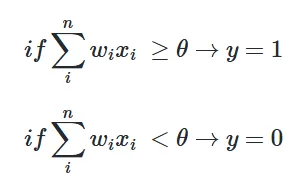         
                 
  2. 편향(bias): 위의 step function 식에서 임계값 좌변으로 넘기면 편향이 됨. 즉 임계값과 표현의 차이이다.            
   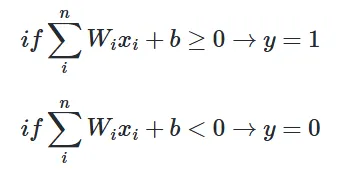

#### 1-2) 단층 퍼셉트론과 그 한계

1. 단층 퍼셉트론: 입력층과 출력층으로만 이루어진 퍼셉트론         
   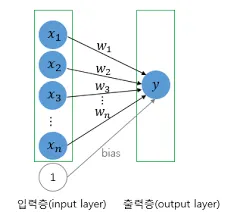         
                  
 * 논리게이트 구현 가능, but **XOR 게이트 구현 불가능**
   + AND게이트: 두개의 입력값이 모두 1인 경우에만 출력값 1이 나오는 구조            
    (ex.[w1,w2,b]=[0.5,0.5,-0,7]일 때 0.5*1 + 0.5*1 - 0.7 =0.3, 0이상이므로 1이 나오게 된다 )     
   + NAND게이트: 두개의 입력값이 1인 경우에만 출력값이 0, 나머지의 입력값 쌍에 대해서는 모두 출력값이 1인 구조
   + OR게이트: 두개의 입력값이 모두 0인 경우에만 출력값이 0이 나오는 구조
   + XOR게이트: 입력값 두 개가 서로 다른 값을 갖고 있을 때만 출력값이 1.        
  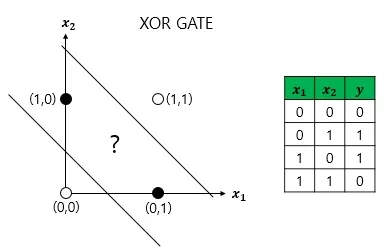          

> 직선 하나로 분류하지 못하므로 선형 분류가 아니다. 퍼셉트론은 직선 하나로 두 영역을 나눌 수 있는 선형 분류 문제에 대해서만 구현 가능.

#### 1-3) 다층 퍼셉트론(MLP; Multi-Layer Perceptron)

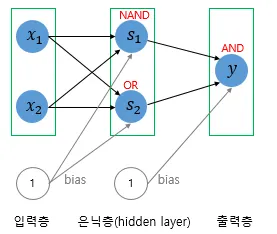

> 퍼셉트론 층을 더 쌓아서 XOR게이트 구현 가능. 즉 중간에 은닉층을 추가하면 된다!

> 두 개 이상의 은닉층을 갖는 MLP가 딥러닝의 시초 모델로 발전함
* 심층 신경망(DNN): 은닉층이 2개 이상인 신경망
* 딥러닝: 심층 신경망을 학습시킴 (가중치를 스스로 찾도록 시킴)
* 퍼셉트론 -> 다층 퍼셉트론 -> 딥러닝 -> 인공싱경망 (ANN)

### 2. 딥러닝 모델의 학습

#### 2-1) 순전파와 역전파
* 학습 알고리즘 기본 구조
  1. 순전파를 통해 입력값으로부터 예측 수행
  2. 오차 계산을 통해 예측 정확도를 측정
  3. 역전파를 통해 출력층에서 다시 입력층 방향으로 오차 전달
  4. 가중치 업데이트
  5. 1~4단계 반복
           
* 연쇄 법칙: 순전파와 역전파의 과정. 서로 얽혀있는 변수 간의 상관관걔를 계산하는 방법이다.
   + 각 은닉층마다 손실에 주는 영향을 곱해서 최종 손실에 대한 값을 나타냄.          
                                 
  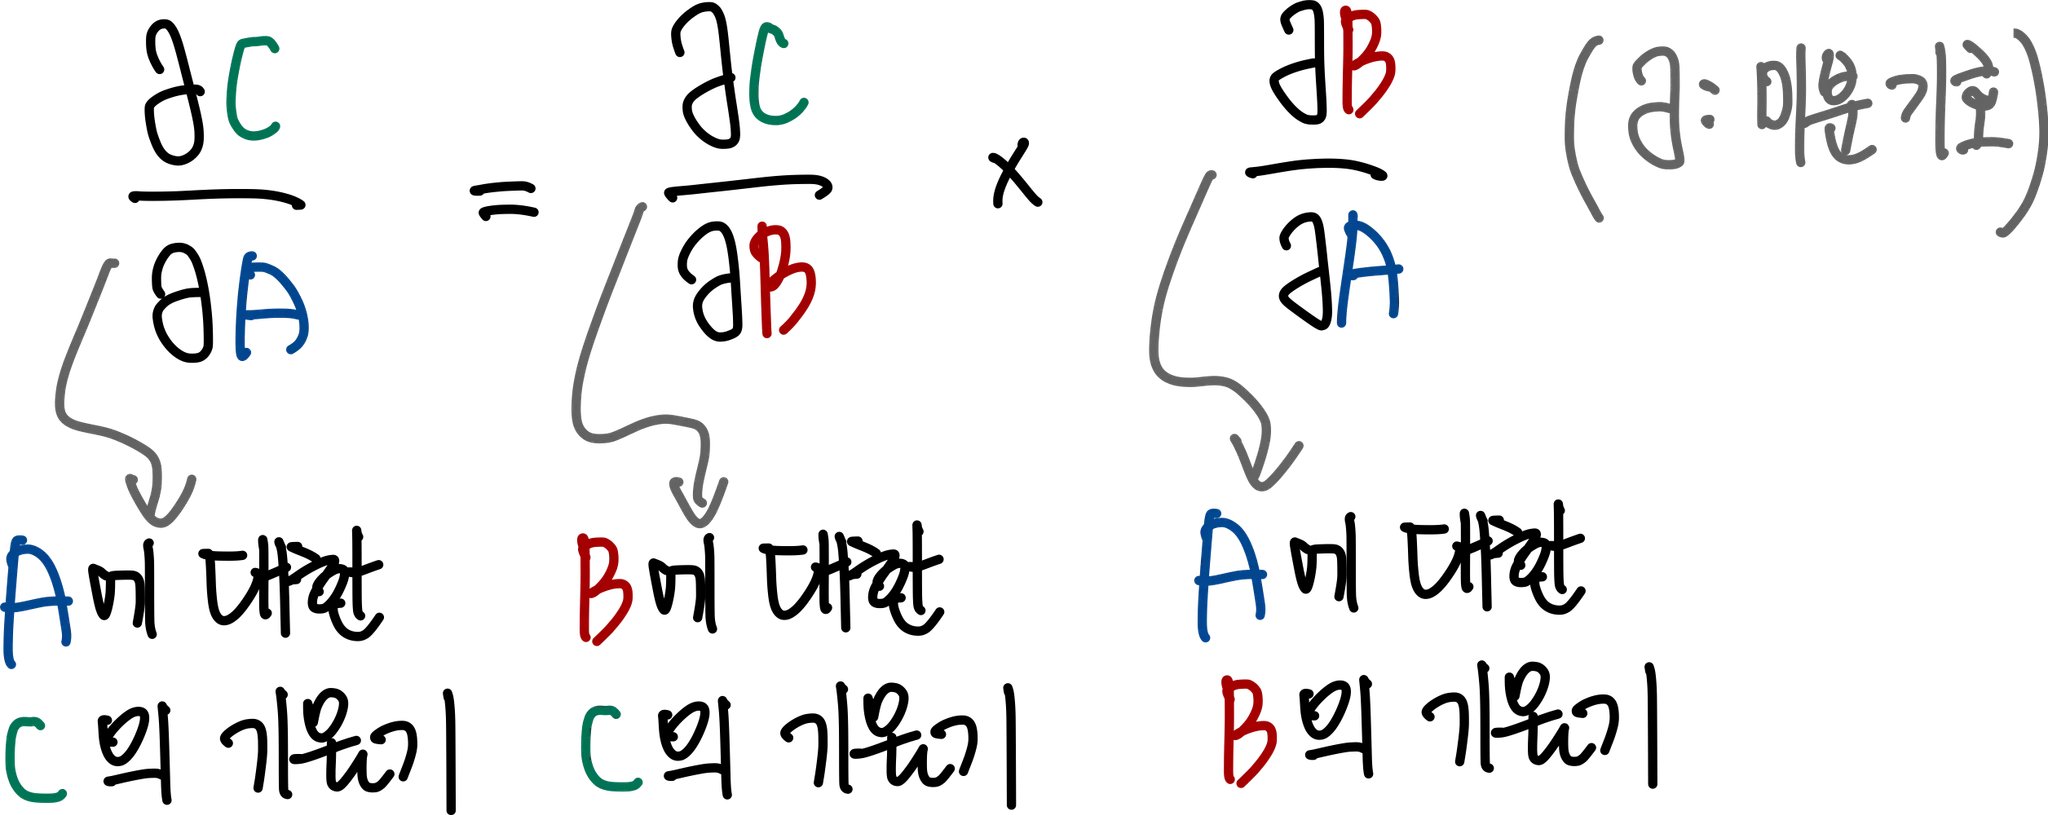            

> A(입력값)으로 인해 발생한 C(결과값)의 오차 = B가 C에 준 영향 * A가 B에 준 영향

  + 그런데 은닉층이 많아지고, 각 단계마다 미분값이 1보다 작은 값이라면 오차(기울기)는 0에 수렴하게 된다. -> **기울기 소실 문제**
  + 딥러닝 모델 성능을 높이려면 오차를 줄이는 것이 필요함
  + 손실함수: 실제값과 예측값의 차이를 수치화한 함수 (출력층의 결과와 정답의 차)
  + 즉 연쇄 법칙 통해 구하는 기울기 = **손실함수 줄이기 위해 가중치를 어떻게 바꿀지** 알려주는 신호임.

#### 2-2) 손실함수 (Loss Function)

* 손실함수의 종류
1. 평균 제곱 오차 (MSE, Mean Squarred Error)
   + 회귀문제에 적합 (예측값이 연속적, 예측값과 실제 값 간 차이 직접 측정)
  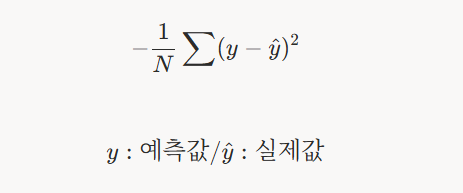

2. 이진 크로스 엔트로피 (BCE, Binary Cross-Entropy Loss)
   + 이진 분류 문제 (로지스틱 회귀)에서 사용
   + 실제 정답과 예측 확률이 비슷할수록(1일때 1, 0일때 0) loss 값이 0에 가까워짐. (안비슷하면 손실값 급증)
   + 즉 실제 정답이 1인데 예측 확률이 0에 가깝다면 모델이 정답에 확신이 없는 것.
   + 실제 정답이 0인데 예측 확률이 1에 가깝다면 모델이 확신을 가지고 틀린 예측을 한 것.
   + 위 두 경우 모두 이 모델이 MSE보다 loss가 더 크다.          
  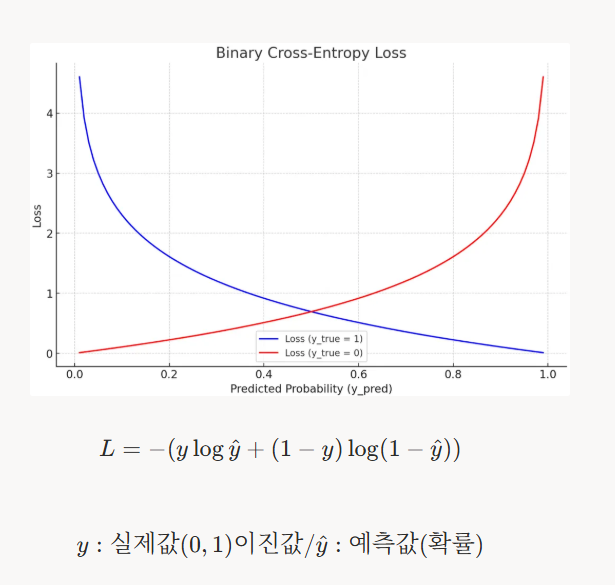

3. 크로스 엔트로피 오차 (CEE, Cross Entropy Error)
   + 다중 클래스 분류 문제에서, 예측 확률이 실제 클래스와 얼마나 일치하는지 평가하는데에 적합.
   + 두 확률 분포(진짜 분포/예측 분포)의 유사도 측정에 유용          
  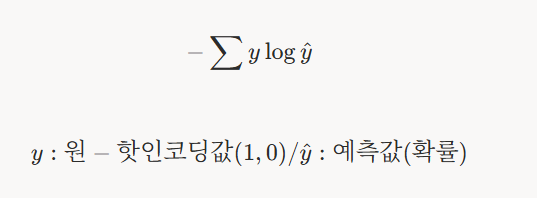

#### 2-3) 활성화 함수(Activation Function)
* 비선형성을 만들어주며, 복잡한 패턴 학습이 가능하게 한다.
* 활성화 함수의 종류
  1. 계단 함수 (단층 퍼셉트론): 입력값과 가중치의 곱 모두 더한 뒤, 특정 기준 넘으면 1 / 아니면 0.        
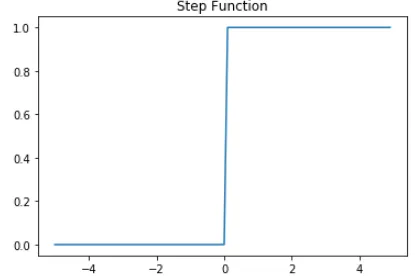          
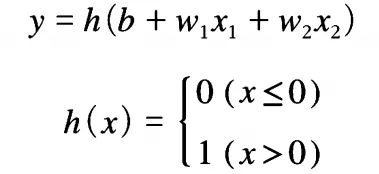         

  2. 시그모이드 함수: 입력 신호를 0~1 사이로 변환하는 역할을 수행. x 값에 따라 y 값이 연속적으로 변한다.        
   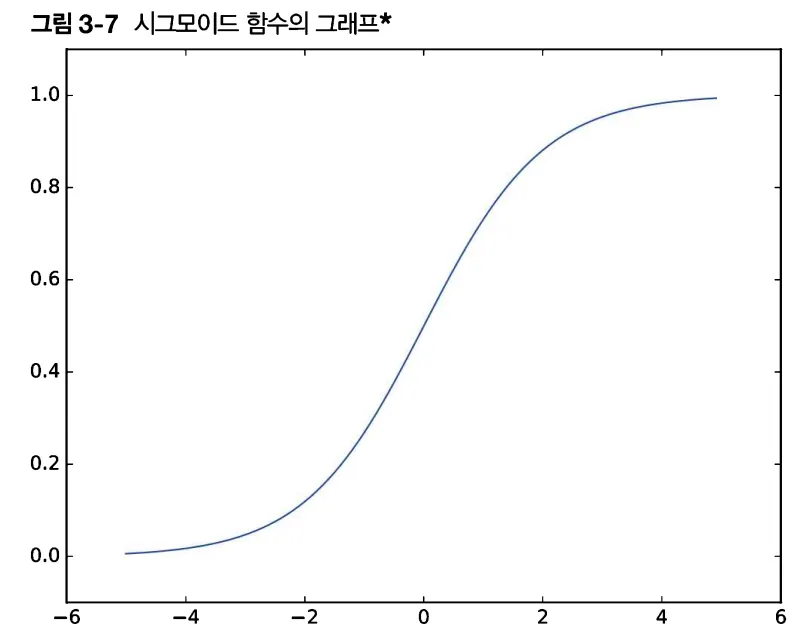         

  3. ReLU 함수: 입력이 0을 넘으면 **입력값을 그대로 출력** 하고, 0이하면 0을 출력하는 비선형 함수. 딥러닝에서 많이 사용한다.         
   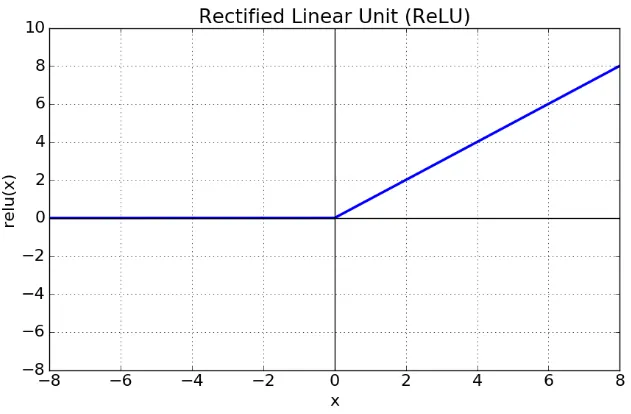         

> ReLU함수의 이점
> 1. 계산이 간단함
> 2. 은닉층에 비선형성 제공
> 3. 같은 신경망에서도 역전파가 잘 전달됨 (기울기 소실 해결)

  4. tanh (hyperbolic tangent, 쌍곡탄젠트 함수): 시그모이드 함수의 변형 (출력값이 -1~1. 입력값의 중심 0으로 맞추고 싶을 때 사용!)         
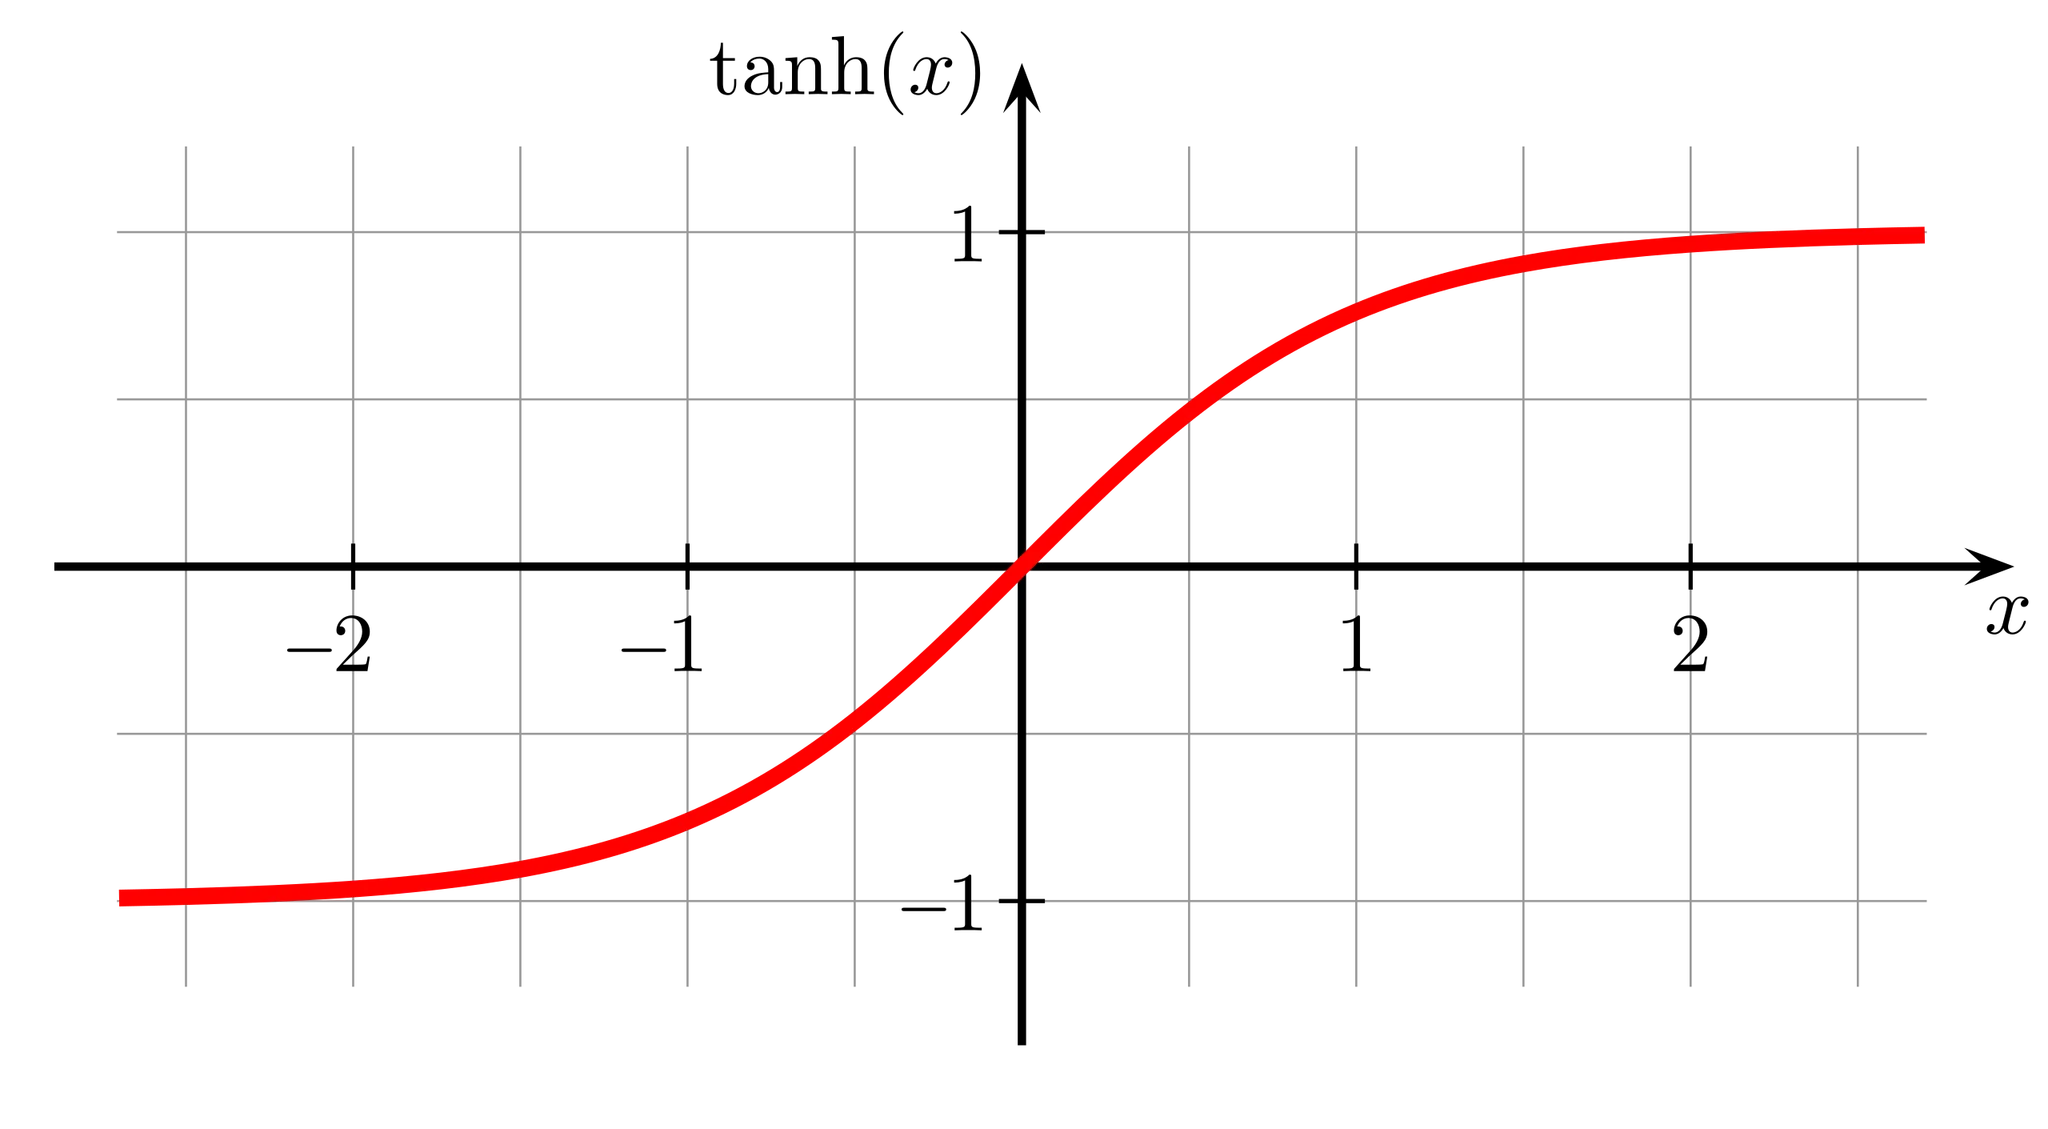

  5. Softmax 함수: 다중 클래스 분류 문제의 활성화 함수로 사용. 출력 값을 확률로 변환하여 개별 클래스의 확률 알 수 있음 (출력값들의 합 1.)
   * 분류문제에서 손실함수와 연결된다. (softmax + 크로스 엔트로피 손실 함수 -> 예측의 확률(softmax)과 정답 확률과의 차(크로스 엔트로피 손실함수)를 바로 계산할 수 있어 학습의 효율 높음. )        
  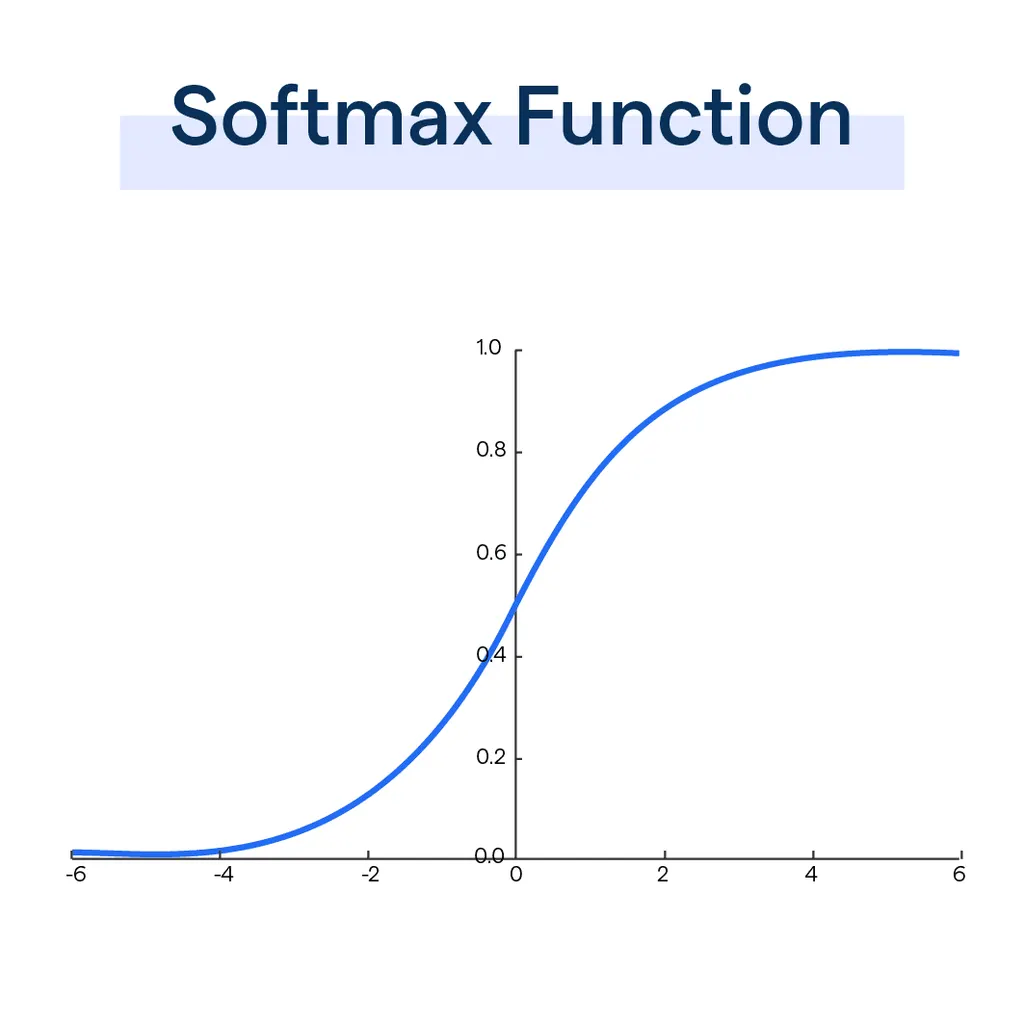

#### 2-4) 경사 하강법: 오차를 가장 작게 만드는 가중치와 편향을 찾는 방법
* 배치(batch): 학습 과정에서 매개변수(가중치 등)를 조정하기 위해 사용하는 데이터의 묶음.
  + 배치의 크기는 사용자가 지정할 수 있는 하이퍼 파라미터임.
  + 너무 크면 학습 느려지고 메모리 부족, 너무 작으면 가중치 자주 업데이트 되며 학습 불안정           
  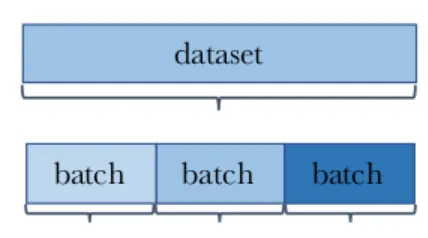             
                         
* 에포크: 모든 데이터셋을 학습하는 횟수 의미.      
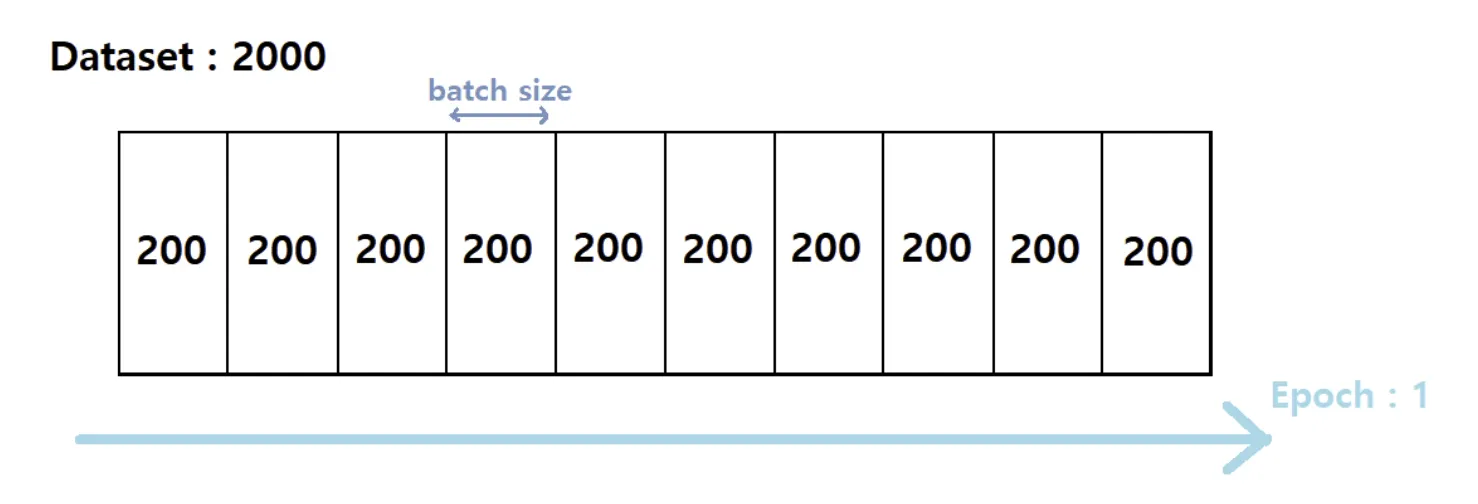           
            
* 이터레이션(스텝): 한 번의 에포크를 끝내기 위해 필요한 배치의 수
* 1 에포크에서 다루는 데이터 수 = 배치의 크기 * 이터레이션

* 딥러닝 경사 하강법의 종류
1. 배치 경사 하강법: 전체 데이터를 한 묶음으로 묶음. (batch size = Data size)
   * 업데이트 횟수가 적다. (1에포크 당 1업데이트 이므로.)
   * 전체 데이터를 모두 한 번에 처리하므로 메모리 많이 필요
   * 항상 같은 데이터(전체)에 대해 경사 구하므로 수렴 안정적           
  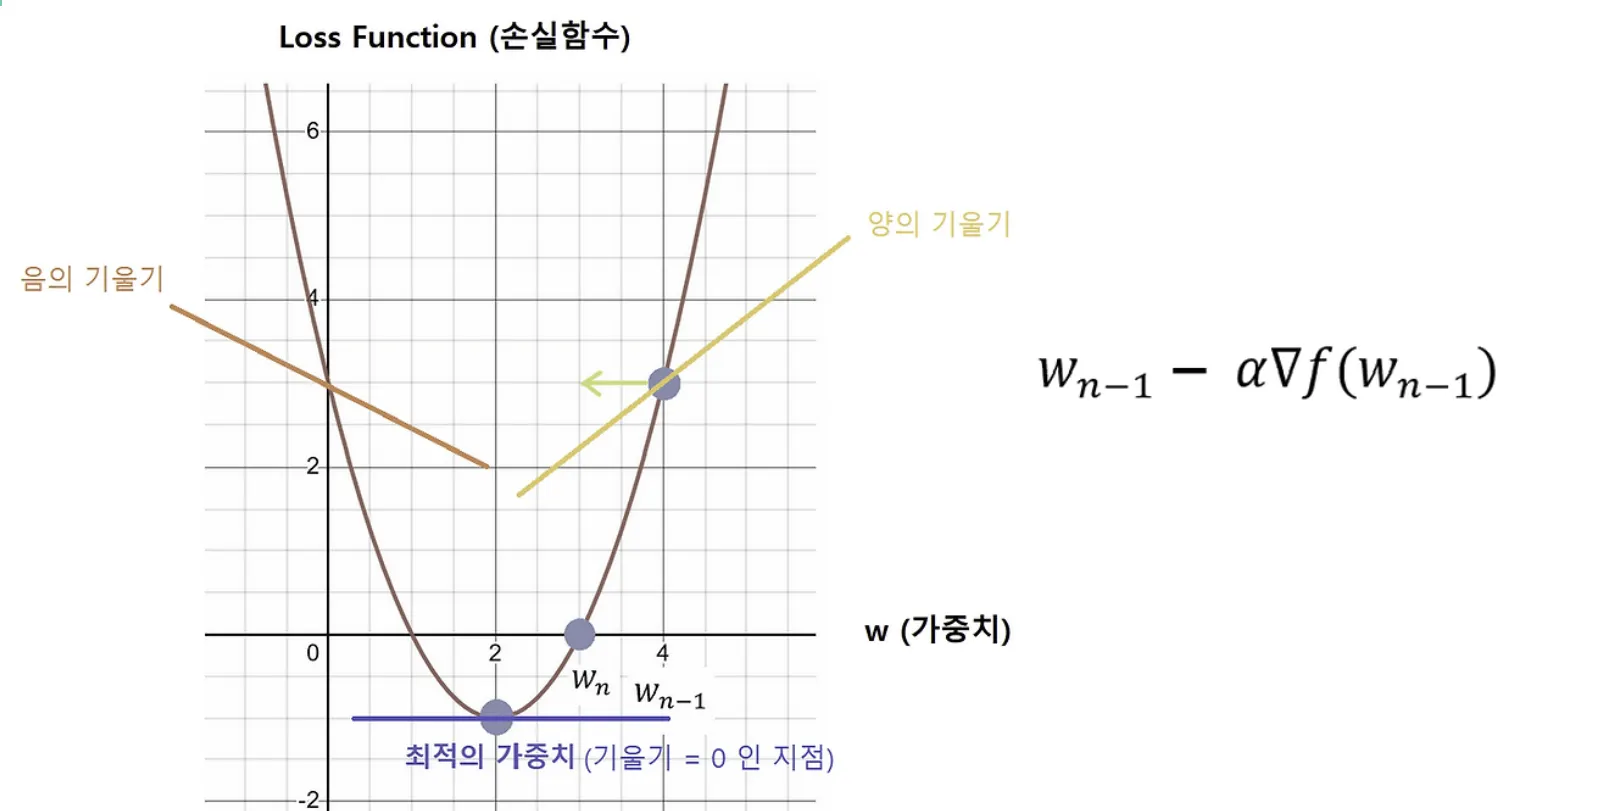             

2. 배치 크기 1인 확률적 경사 하강법 (SGD, Stochastic Gradient Descent)
   * 랜덤으로 선택된 하나의 데이터에 대해서만 계산함. -> 더 빠르게 계산 가능
   * 메모리 사용 적음
   * 그러나 매개변수 변경폭이 불안정하고 정확도 낮을 수 있음       
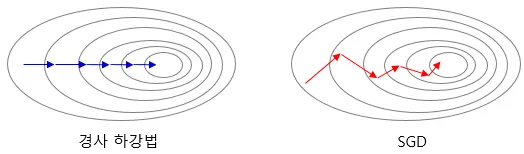         

3. 미니 배치 경사 하강법 (Mini-batch Gradient Descent)
   * 배치 사이즈 적절히 지정해 (일반적으로 2^n에 해당하는 숫자 선택, 별도 지정 없다면 2^5) 해당 데이터 개수 만큼에 대해 매개변수 값 조정 (계산)
   * 전체 데이터 계산보다는 빠르고, 배치 크기 1인 경사하강법 보다는 안정적임. 가장 많이 사용!            
  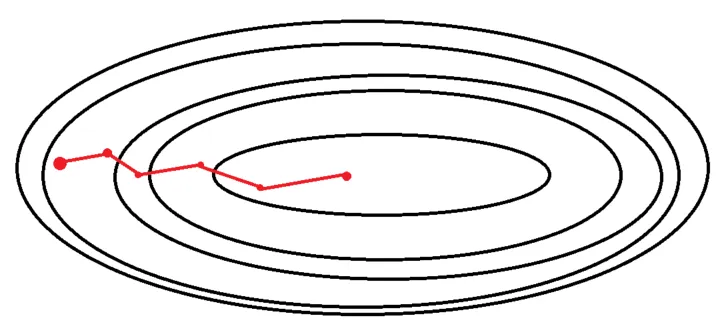    

#### 2-5) 옵티마이저
* 경사하강법을 더 효율적, 안정적으로 수행하기 위해 필요한 것. 경사하강법에서 옵티마이저를 통해 더 효과적인 최솟값 찾을 수 있다.       
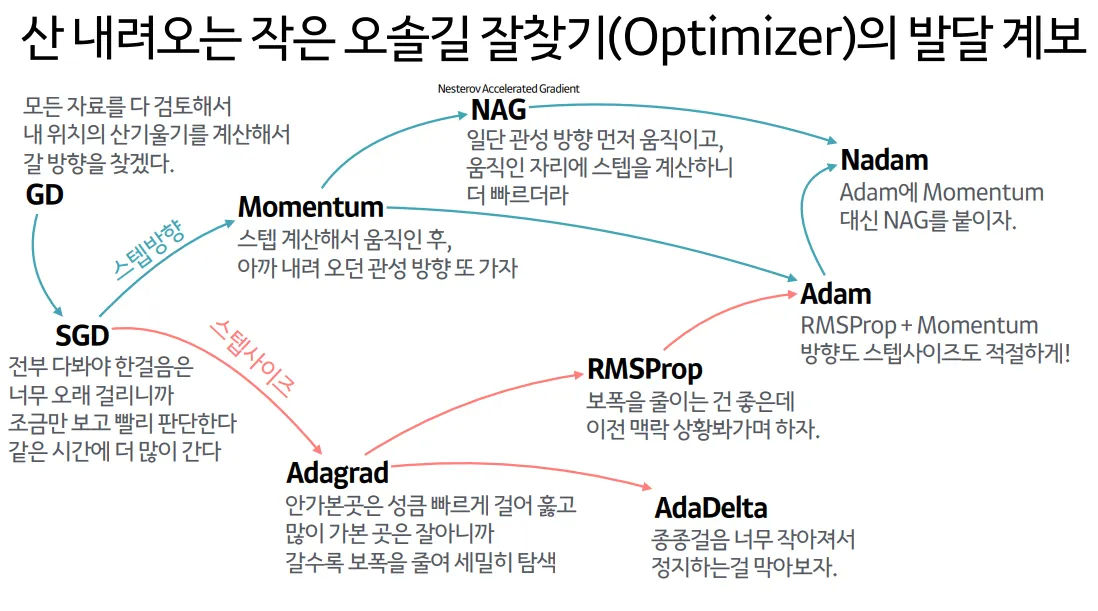    

1. 모멘텀
   * 경사하강법 + 관성 (변수가 가던 방향으로 계속 가도록 함.)
   * 경사하강법에서 계산된 미분값에 바로 한 시점 전의 미분값을 학습률만큼 반영함.        
  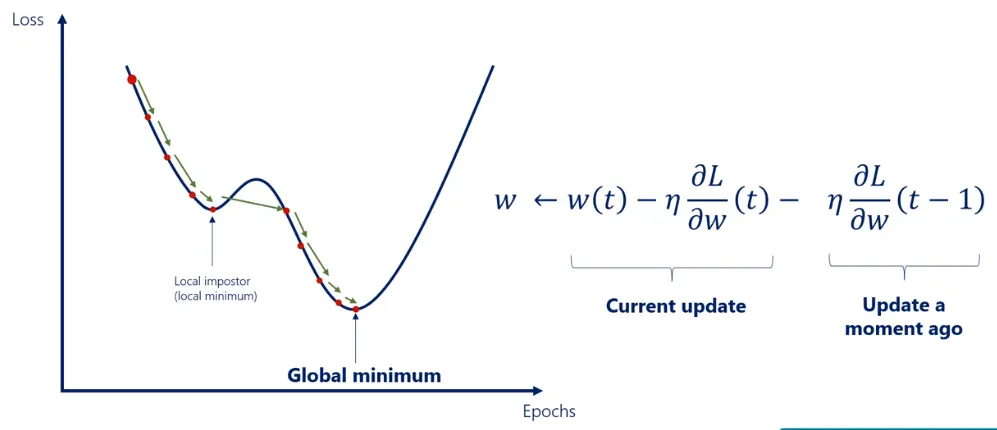

2. RMSProp
   * 기존 경사하강법의 문제인 큰 방향에서 너무 많이, 작은 방향에선 너무 작게 이동하는 문제를 해결.
   * 미분 절대값이 클 때 학습률 작게하고, 미분 절대값이 작을 때 학습률 크게 해서 안정적으로 값 찾음.          
  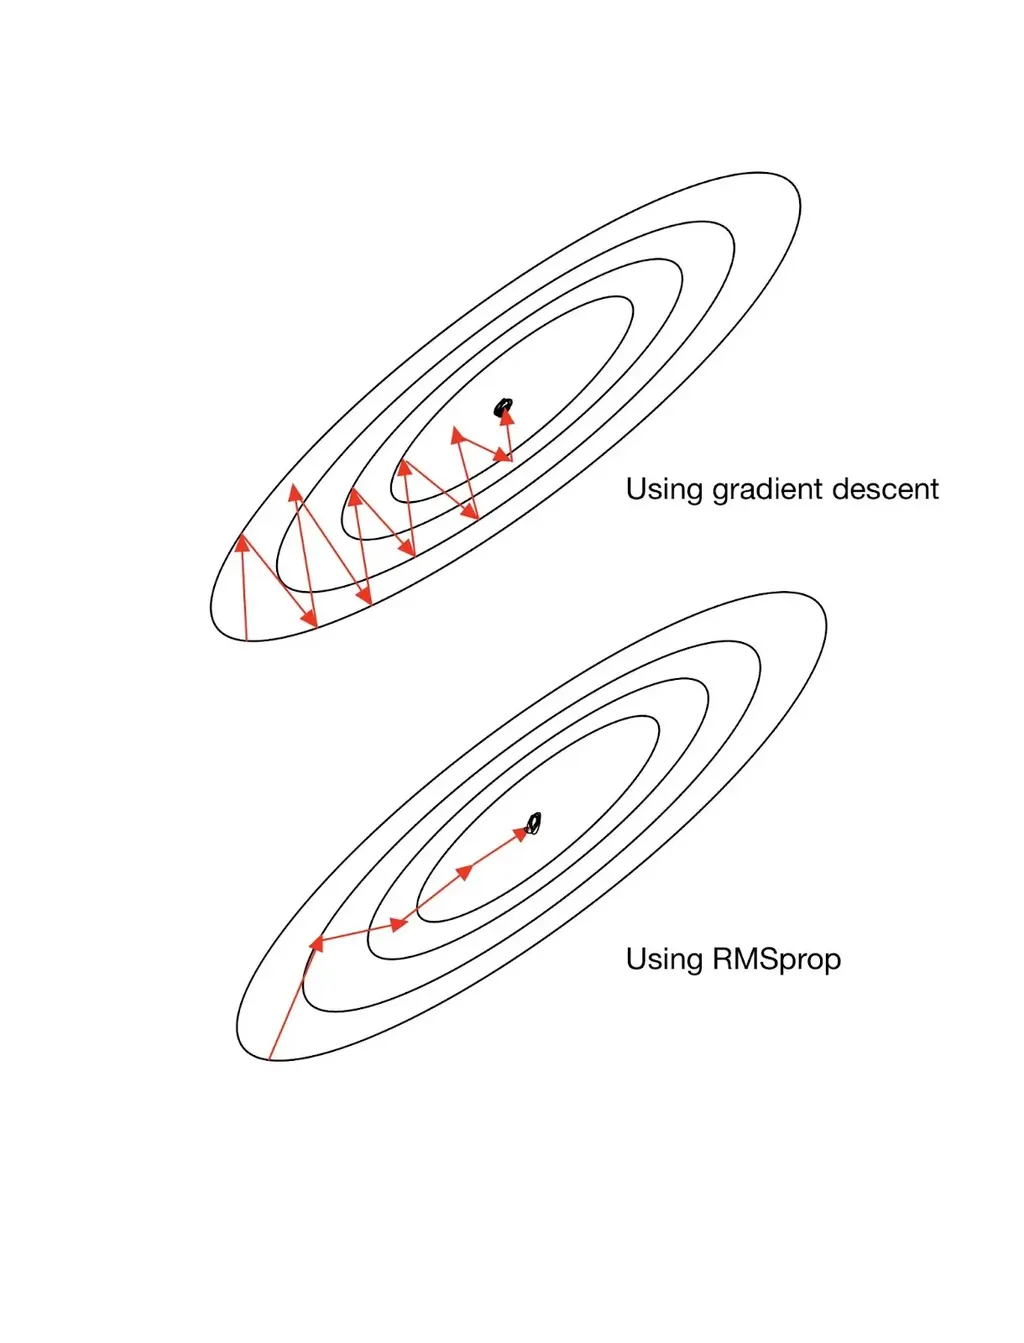

3. 아담(Adam)
   * RMSProp과 모멘텀 합친, 방향과 스텝 사이즈 적절히 합친 방법.
   * 각 파라미터의 1차 모멘트(기울기의 평균)와 2차 모멘트(기울기의 제곱 평균)를 사용하여 학습률을 조정한다.

#### 2-6) 데이터 증강
* 데이터 증강: 데이터를 조금씩 변형해 학습 데이터 늘림
   1. 모델 성능 향상: 다양한 변형들 학습해 일반화된 패턴 익힘
   2. 데이터 의존성 감소: 다양한 패턴 학습해 원본과 조금 달라도 작동할 수 있게.
   3. 과적합 완화: 다양한 입력값 갖게 해 과적합 감소.
   4. 데이터 프라이버시 보호: 원본 데이터 노출 최소화하며 성능 향상.
               
